In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0032.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0026.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0040.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0056.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0009.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0011.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0018.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0005.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0051.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0014.npy
/kaggle/input/datasets/jorgeoc

In [2]:
# =========================
# CELDA 1: Imports
# =========================
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn


In [3]:
# =========================
# CELDA 2: Arquitecturas
# =========================
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=5, dilation=1, drop=0.1):
        super().__init__()
        pad = (k - 1) * dilation // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, k, padding=pad, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, k, padding=pad, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.act = nn.ReLU()
        self.drop = nn.Dropout(drop)
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        s = self.skip(x)
        x = self.drop(self.act(self.bn1(self.conv1(x))))
        x = self.drop(self.act(self.bn2(self.conv2(x))))
        return self.act(x + s)

class IntentTCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
        )
        self.tcn = nn.Sequential(
            TCNBlock(16, 16, dilation=1, drop=0.10),
            TCNBlock(16, 32, dilation=2, drop=0.10),
            TCNBlock(32, 32, dilation=4, drop=0.10),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.tcn(x)
        x = self.pool(x)
        return self.head(x)

class QualityNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, 5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, 5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        self.head_score = nn.Linear(32, 1)
        self.head_label = nn.Linear(32, 1)

    def forward(self, x):
        z = self.features(x)
        z = self.shared(z)
        q_score = torch.sigmoid(self.head_score(z))
        q_logit = self.head_label(z)
        return q_score, q_logit

class ConvAE1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, 5, stride=2, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.Conv1d(16, 32, 5, stride=2, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Conv1d(32, 64, 5, stride=2, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )
        self.bottleneck = nn.Sequential(
            nn.Conv1d(64, 64, 3, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 32, 4, stride=2, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.ConvTranspose1d(32, 16, 4, stride=2, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.ConvTranspose1d(16, 1, 4, stride=2, padding=1),
        )

    def forward(self, x):
        z = self.encoder(x)
        z = self.bottleneck(z)
        y = self.decoder(z)
        return y


In [4]:
# =========================
# CELDA 3: Cargar modelos
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

MODELS_DIR = "/kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1"

intent_model = IntentTCN().to(device)
intent_model.load_state_dict(torch.load(f"{MODELS_DIR}/intent_binary_best.pt", map_location=device))
intent_model.eval()

quality_model = QualityNet().to(device)
quality_model.load_state_dict(torch.load(f"{MODELS_DIR}/quality_judge_best.pt", map_location=device))
quality_model.eval()

restorer_model = ConvAE1D().to(device)
restorer_model.load_state_dict(torch.load(f"{MODELS_DIR}/restorer_best.pt", map_location=device))
restorer_model.eval()

print("Modelos cargados correctamente.")


device: cpu
Modelos cargados correctamente.


In [5]:
# =========================
# CELDA 4: Utilidades
# =========================
def mae_np(a, b):
    return float(np.mean(np.abs(a - b)))

def mse_np(a, b):
    return float(np.mean((a - b) ** 2))

def snr_db(clean, noisy):
    noise = noisy - clean
    ps = np.mean(clean**2) + 1e-8
    pn = np.mean(noise**2) + 1e-8
    return float(10 * np.log10(ps / pn))

def corrcoef_1d(a, b):
    a = np.asarray(a).reshape(-1)
    b = np.asarray(b).reshape(-1)
    if np.std(a) < 1e-8 or np.std(b) < 1e-8:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])


In [6]:
# =========================
# CELDA 5: Política del pipeline
# =========================
THR_INTENT = 0.50
THR_QUALITY = 0.50

@torch.no_grad()
def run_pipeline_on_batch(x_batch, thr_intent=0.50, thr_quality=0.50):
    xb = torch.tensor(x_batch, dtype=torch.float32, device=device)

    intent_logits = intent_model(xb)
    p_intent = torch.sigmoid(intent_logits).cpu().numpy().reshape(-1)

    q_score_pred, q_logit = quality_model(xb)
    q_score_pred = q_score_pred.cpu().numpy().reshape(-1)
    q_prob_good = torch.sigmoid(q_logit).cpu().numpy().reshape(-1)

    out = []
    restored = []

    for i in range(len(x_batch)):
        pi = float(p_intent[i])
        qg = float(q_prob_good[i])
        qs = float(q_score_pred[i])

        if pi < thr_intent:
            decision = "skip_restore"
            reason = "no_intent_detected"
        elif qg >= thr_quality:
            decision = "skip_restore"
            reason = "signal_quality_good_enough"
        else:
            decision = "restore"
            reason = "intent_detected_and_quality_bad"

        if decision == "restore":
            xr = restorer_model(xb[i:i+1]).cpu().numpy()[0]
        else:
            xr = x_batch[i].copy()

        restored.append(xr)
        out.append({
            "p_intent": pi,
            "q_score_pred": qs,
            "q_prob_good": qg,
            "decision": decision,
            "reason": reason
        })

    return out, np.stack(restored).astype(np.float32)


In [7]:
# =========================
# CELDA 6: Cargar secuencia del dataset
# =========================
candidate_dirs = []
for p in glob.glob("/kaggle/input/**/restoration_dataset", recursive=True):
    if os.path.isdir(p):
        xcorr = glob.glob(os.path.join(p, "Xcorr_*.npy"))
        xclean = glob.glob(os.path.join(p, "Xclean_*.npy"))
        qscore = glob.glob(os.path.join(p, "Qscore_*.npy"))
        if len(xcorr) > 0 and len(xclean) > 0 and len(qscore) > 0:
            candidate_dirs.append(p)

print("Candidatos encontrados:")
for c in candidate_dirs:
    print(" -", c)

if not candidate_dirs:
    raise FileNotFoundError("No encontré restoration_dataset.")

RDIR = candidate_dirs[0]
Xcorr_files = sorted(glob.glob(os.path.join(RDIR, "Xcorr_*.npy")))
Xclean_files = sorted(glob.glob(os.path.join(RDIR, "Xclean_*.npy")))

# tomar una secuencia más larga
x_corr = np.load(Xcorr_files[0])
x_clean = np.load(Xclean_files[0])

NSEQ = min(1000, len(x_corr))
x_corr_seq = x_corr[:NSEQ]
x_clean_seq = x_clean[:NSEQ]

print("x_corr_seq:", x_corr_seq.shape)
print("x_clean_seq:", x_clean_seq.shape)


Candidatos encontrados:
 - /kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset
x_corr_seq: (1000, 1, 400)
x_clean_seq: (1000, 1, 400)


In [8]:
# =========================
# CELDA 7: Simulación completa
# =========================
rows_seq, x_out_seq = run_pipeline_on_batch(
    x_corr_seq,
    thr_intent=THR_INTENT,
    thr_quality=THR_QUALITY
)

records = []
for i, row in enumerate(rows_seq):
    clean = x_clean_seq[i, 0]
    corr  = x_corr_seq[i, 0]
    out   = x_out_seq[i, 0]

    records.append({
        "idx": i,
        **row,
        "mae_before": mae_np(clean, corr),
        "mae_after": mae_np(clean, out),
        "snr_before": snr_db(clean, corr),
        "snr_after": snr_db(clean, out),
        "corr_before": corrcoef_1d(clean, corr),
        "corr_after": corrcoef_1d(clean, out),
        "improved_mae": mae_np(clean, out) < mae_np(clean, corr),
        "improved_snr": snr_db(clean, out) > snr_db(clean, corr),
    })

df_seq = pd.DataFrame(records)
df_seq.head()


,idx,p_intent,q_score_pred,q_prob_good,decision,reason,mae_before,mae_after,snr_before,snr_after,corr_before,corr_after,improved_mae,improved_snr
0,0,0.885436,0.365642,0.000270,restore,intent_detected_and_quality_bad,2.026802,0.351064,6.711089,20.611811,0.965357,0.992565,True,True
1,1,0.278118,0.950326,0.996506,skip_restore,no_intent_detected,0.078784,0.078784,34.546993,34.546993,0.999728,0.999728,False,False
2,2,0.940655,0.999781,0.999999,skip_restore,signal_quality_good_enough,0.282560,0.282560,27.999830,27.999830,0.992411,0.992411,False,False
3,3,0.620910,0.423496,0.004911,restore,intent_detected_and_quality_bad,1.877942,0.362255,8.383072,21.052399,0.903180,0.981195,True,True
4,4,0.924139,0.999703,1.000000,skip_restore,signal_quality_good_enough,0.148471,0.148471,33.528049,33.528049,0.998370,0.998370,False,False


In [9]:
# =========================
# CELDA 8: Resumen del simulador
# =========================
print("Conteo de decisiones:")
print(df_seq["decision"].value_counts(dropna=False))
print()

print("Razones:")
print(df_seq["reason"].value_counts(dropna=False))
print()

print("Promedios globales:")
print(df_seq[["mae_before", "mae_after", "snr_before", "snr_after", "corr_before", "corr_after"]].mean())
print()

dfr = df_seq[df_seq["decision"] == "restore"]
print("Solo restauradas:")
print(dfr[["mae_before", "mae_after", "snr_before", "snr_after", "corr_before", "corr_after"]].mean())
print("Frac mejora MAE:", dfr["improved_mae"].mean())
print("Frac mejora SNR:", dfr["improved_snr"].mean())


Conteo de decisiones:
decision
skip_restore    755
restore         245
Name: count, dtype: int64

Razones:
reason
signal_quality_good_enough         538
intent_detected_and_quality_bad    245
no_intent_detected                 217
Name: count, dtype: int64

Promedios globales:
mae_before      1.015622
mae_after       0.464058
snr_before     25.024514
snr_after      27.977367
corr_before     0.930823
corr_after      0.956387
dtype: float64

Solo restauradas:
mae_before      2.823178
mae_after       0.571896
snr_before      5.972965
snr_after      18.025427
corr_before     0.835948
corr_after      0.940292
dtype: float64
Frac mejora MAE: 0.9714285714285714
Frac mejora SNR: 0.9795918367346939


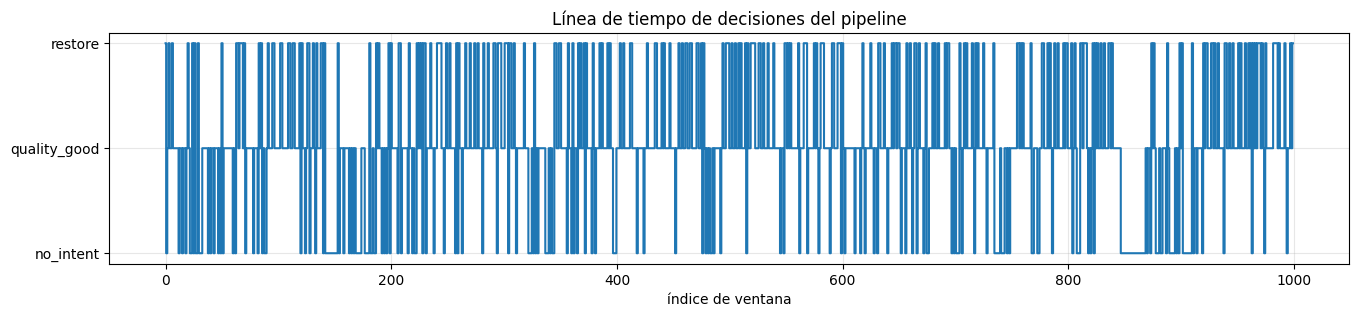

In [10]:
# =========================
# CELDA 9: Línea de tiempo de decisiones
# =========================
decision_map = {
    "no_intent_detected": 0,
    "signal_quality_good_enough": 1,
    "intent_detected_and_quality_bad": 2
}

timeline = df_seq["reason"].map(decision_map).values

plt.figure(figsize=(16, 3))
plt.plot(timeline, drawstyle="steps-mid")
plt.yticks([0, 1, 2], ["no_intent", "quality_good", "restore"])
plt.xlabel("índice de ventana")
plt.title("Línea de tiempo de decisiones del pipeline")
plt.grid(True, alpha=0.3)
plt.show()


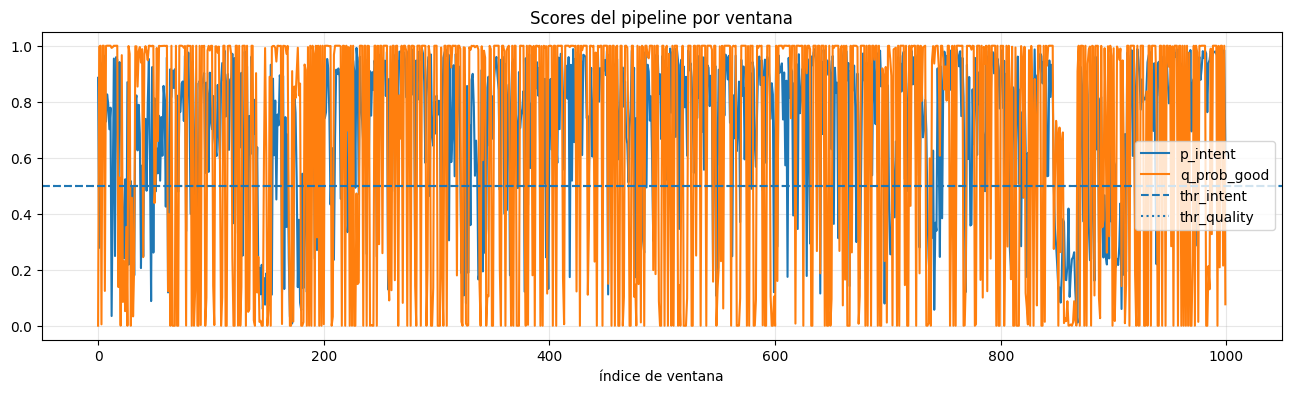

In [11]:
# =========================
# CELDA 10: Scores del pipeline
# =========================
plt.figure(figsize=(16,4))
plt.plot(df_seq["p_intent"].values, label="p_intent")
plt.plot(df_seq["q_prob_good"].values, label="q_prob_good")
plt.axhline(THR_INTENT, linestyle="--", label="thr_intent")
plt.axhline(THR_QUALITY, linestyle=":", label="thr_quality")
plt.legend()
plt.title("Scores del pipeline por ventana")
plt.xlabel("índice de ventana")
plt.grid(True, alpha=0.3)
plt.show()


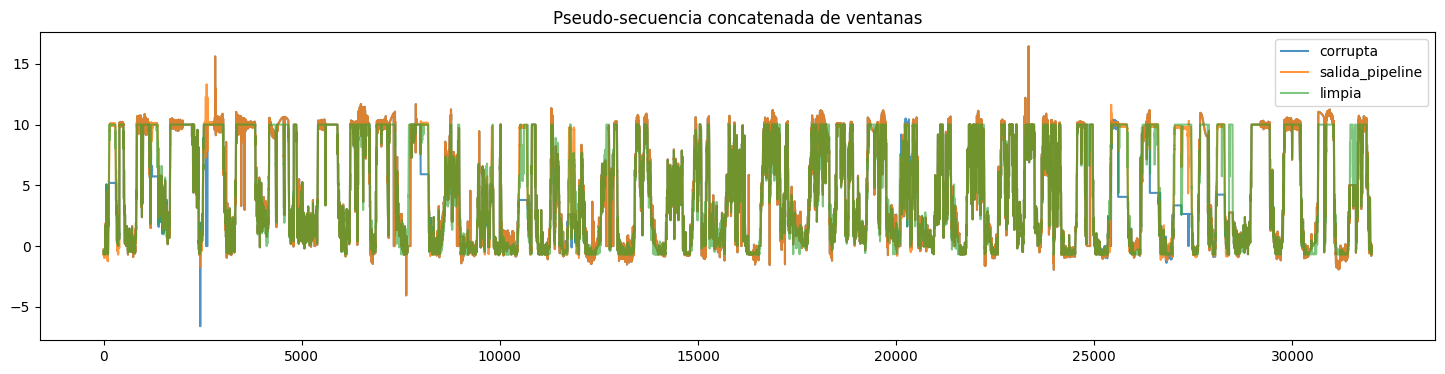

In [12]:
# =========================
# CELDA 11: Señal concatenada antes/después
# =========================
# concatenar primeras ventanas para visualización
K = min(80, len(x_corr_seq))

sig_corr = np.concatenate([x_corr_seq[i,0] for i in range(K)])
sig_out  = np.concatenate([x_out_seq[i,0] for i in range(K)])
sig_clean = np.concatenate([x_clean_seq[i,0] for i in range(K)])

plt.figure(figsize=(18,4))
plt.plot(sig_corr, label="corrupta", alpha=0.8)
plt.plot(sig_out, label="salida_pipeline", alpha=0.8)
plt.plot(sig_clean, label="limpia", alpha=0.6)
plt.legend()
plt.title("Pseudo-secuencia concatenada de ventanas")
plt.show()


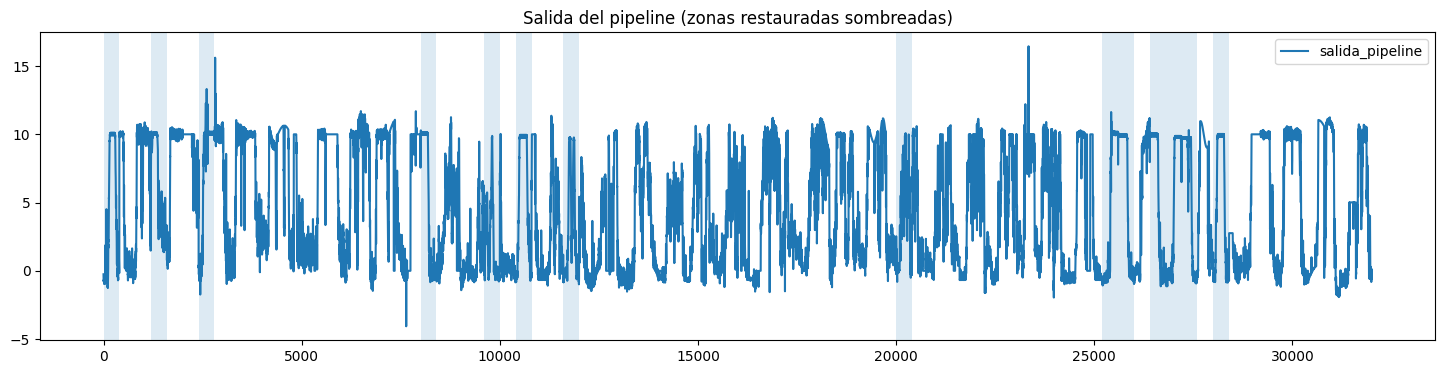

In [13]:
# =========================
# CELDA 12: Zonas restauradas marcadas
# =========================
K = min(80, len(df_seq))
win_len = x_corr_seq.shape[-1]

plt.figure(figsize=(18,4))
plt.plot(sig_out, label="salida_pipeline")

for i in range(K):
    if df_seq.iloc[i]["decision"] == "restore":
        x0 = i * win_len
        x1 = (i + 1) * win_len
        plt.axvspan(x0, x1, alpha=0.15)

plt.title("Salida del pipeline (zonas restauradas sombreadas)")
plt.legend()
plt.show()


idx=0
decision=restore | reason=intent_detected_and_quality_bad
p_intent=0.885, q_prob_good=0.000, q_score_pred=0.366
MAE: 2.0268 -> 0.3511
SNR: 6.71 -> 20.61



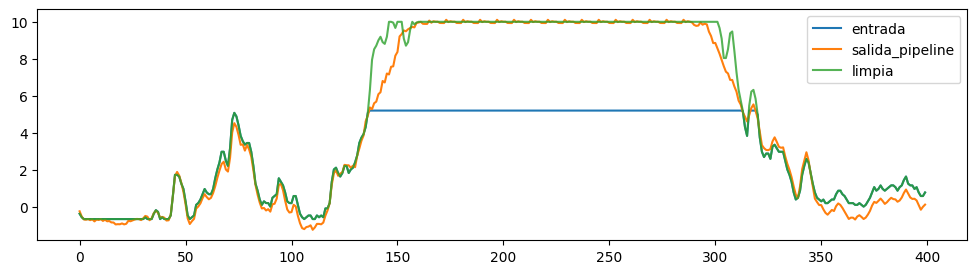

idx=1
decision=skip_restore | reason=no_intent_detected
p_intent=0.278, q_prob_good=0.997, q_score_pred=0.950
MAE: 0.0788 -> 0.0788
SNR: 34.55 -> 34.55



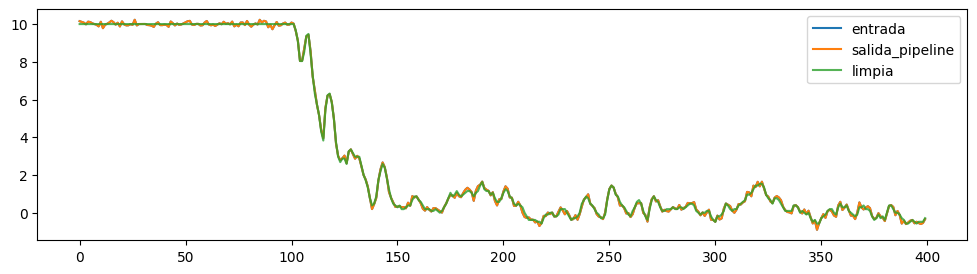

idx=2
decision=skip_restore | reason=signal_quality_good_enough
p_intent=0.941, q_prob_good=1.000, q_score_pred=1.000
MAE: 0.2826 -> 0.2826
SNR: 28.00 -> 28.00



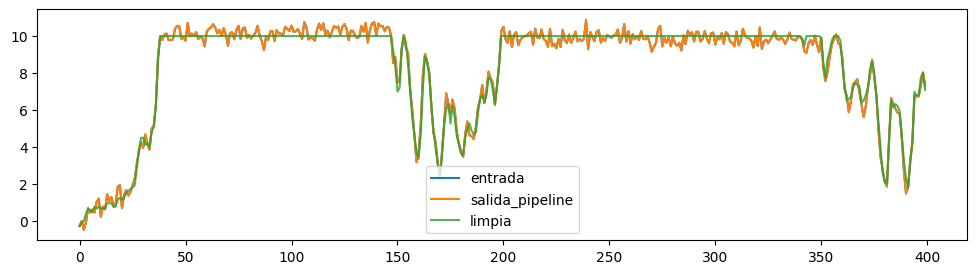

idx=3
decision=restore | reason=intent_detected_and_quality_bad
p_intent=0.621, q_prob_good=0.005, q_score_pred=0.423
MAE: 1.8779 -> 0.3623
SNR: 8.38 -> 21.05



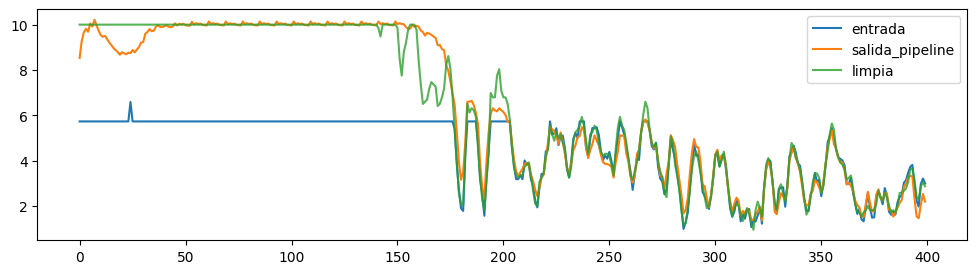

idx=4
decision=skip_restore | reason=signal_quality_good_enough
p_intent=0.924, q_prob_good=1.000, q_score_pred=1.000
MAE: 0.1485 -> 0.1485
SNR: 33.53 -> 33.53



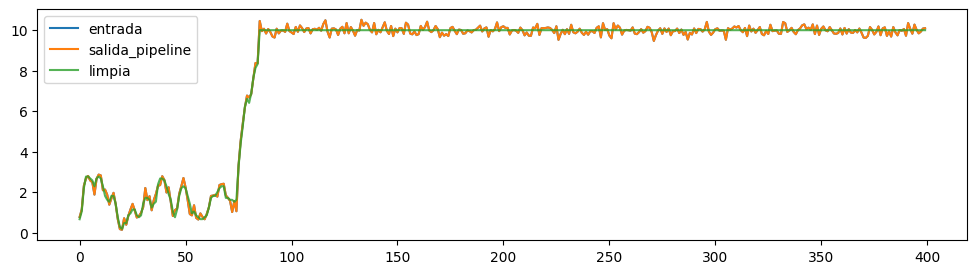

idx=5
decision=skip_restore | reason=signal_quality_good_enough
p_intent=0.965, q_prob_good=1.000, q_score_pred=1.000
MAE: 0.0000 -> 0.0000
SNR: 99.05 -> 99.05



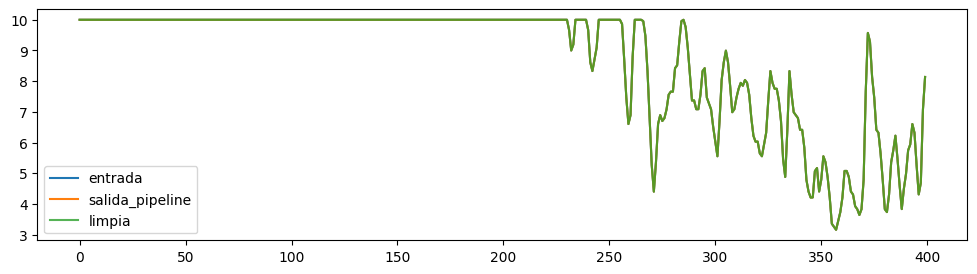

In [14]:
# =========================
# CELDA 13: Ventanas cercanas
# =========================
start_idx = 0
num_show = 6

for i in range(start_idx, min(start_idx + num_show, len(df_seq))):
    row = df_seq.iloc[i]
    clean = x_clean_seq[i,0]
    corr  = x_corr_seq[i,0]
    out   = x_out_seq[i,0]

    print(f"idx={i}")
    print(f"decision={row['decision']} | reason={row['reason']}")
    print(f"p_intent={row['p_intent']:.3f}, q_prob_good={row['q_prob_good']:.3f}, q_score_pred={row['q_score_pred']:.3f}")
    print(f"MAE: {row['mae_before']:.4f} -> {row['mae_after']:.4f}")
    print(f"SNR: {row['snr_before']:.2f} -> {row['snr_after']:.2f}")
    print()

    plt.figure(figsize=(12,3))
    plt.plot(corr, label="entrada")
    plt.plot(out, label="salida_pipeline")
    plt.plot(clean, label="limpia", alpha=0.8)
    plt.legend()
    plt.show()


In [15]:
# =========================
# CELDA 14: Señal sintética larga
# =========================
def make_synthetic_sequence(num_windows=30, T=400, seed=123):
    rng = np.random.default_rng(seed)
    x_clean_list = []
    x_corr_list = []

    for i in range(num_windows):
        t = np.linspace(0, 1, T)

        if i % 3 == 0:
            # reposo / casi sin gesto
            clean = np.zeros(T, dtype=np.float32)
            clean += 0.02 * rng.normal(size=T).astype(np.float32)
        else:
            env = np.exp(-0.5 * ((t - 0.5) / 0.12)**2)
            carrier = np.sin(2*np.pi*35*t) + 0.5*np.sin(2*np.pi*70*t)
            clean = (env * carrier).astype(np.float32)

        noisy = clean.copy()
        noisy += rng.normal(0, 0.25, size=T).astype(np.float32)

        if i % 4 == 0:
            noisy += (0.5 * np.sin(2*np.pi*1.2*t)).astype(np.float32)

        if i % 5 == 0:
            start = 120
            noisy[start:start+50] = 0.0

        x_clean_list.append(clean[None, :])
        x_corr_list.append(noisy[None, :])

    x_clean = np.stack(x_clean_list).astype(np.float32)
    x_corr = np.stack(x_corr_list).astype(np.float32)
    return x_clean, x_corr

x_clean_syn, x_corr_syn = make_synthetic_sequence(num_windows=30)
rows_syn, x_out_syn = run_pipeline_on_batch(x_corr_syn, thr_intent=THR_INTENT, thr_quality=THR_QUALITY)

df_syn = pd.DataFrame(rows_syn)
print(df_syn["decision"].value_counts(dropna=False))
print(df_syn["reason"].value_counts(dropna=False))


decision
skip_restore    30
Name: count, dtype: int64
reason
no_intent_detected    30
Name: count, dtype: int64


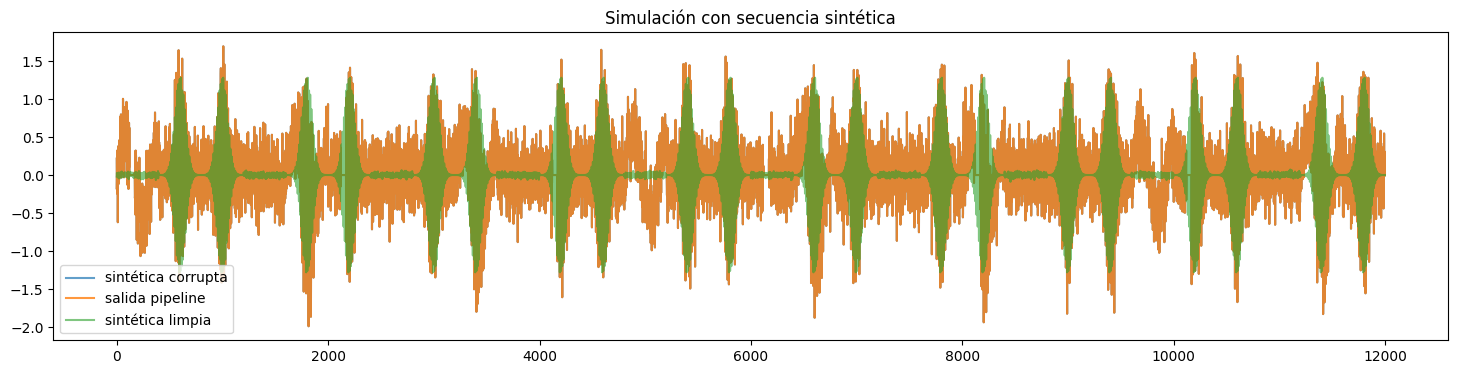

In [16]:
# =========================
# CELDA 15: Visualizar secuencia sintética
# =========================
sig_corr_syn = np.concatenate([x_corr_syn[i,0] for i in range(len(x_corr_syn))])
sig_out_syn  = np.concatenate([x_out_syn[i,0] for i in range(len(x_out_syn))])
sig_clean_syn = np.concatenate([x_clean_syn[i,0] for i in range(len(x_clean_syn))])

plt.figure(figsize=(18,4))
plt.plot(sig_corr_syn, label="sintética corrupta", alpha=0.7)
plt.plot(sig_out_syn, label="salida pipeline", alpha=0.8)
plt.plot(sig_clean_syn, label="sintética limpia", alpha=0.6)
plt.legend()
plt.title("Simulación con secuencia sintética")
plt.show()


In [17]:
# =========================
# CELDA 16: Señal externa tipo MyoWare
# =========================
external_path = None
# Ejemplos:
# external_path = "/kaggle/input/mi-senal/senal.npy"
# external_path = "/kaggle/input/mi-senal/senal.csv"
# external_path = "/kaggle/input/mi-senal/senal.txt"

def robust_norm_1d(x):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-6
    z = (x - med) / (1.4826 * mad)
    return np.clip(z, -10, 10).astype(np.float32)

def load_external_signal(path):
    if path.endswith(".npy"):
        sig = np.load(path).astype(np.float32).reshape(-1)
    elif path.endswith(".csv"):
        sig = np.loadtxt(path, delimiter=",", dtype=np.float32).reshape(-1)
    elif path.endswith(".txt"):
        sig = np.loadtxt(path, dtype=np.float32).reshape(-1)
    else:
        raise ValueError("Formato no soportado. Usa .npy, .csv o .txt")
    return robust_norm_1d(sig)

def windows_1d(sig, win=400, stride=200):
    idxs = np.arange(0, len(sig) - win + 1, stride)
    return np.stack([sig[i:i+win] for i in idxs], axis=0)[:, None, :].astype(np.float32)

if external_path is not None:
    sig_ext = load_external_signal(external_path)
    x_ext = windows_1d(sig_ext, win=400, stride=200)

    rows_ext, x_out_ext = run_pipeline_on_batch(x_ext, thr_intent=THR_INTENT, thr_quality=THR_QUALITY)
    df_ext = pd.DataFrame(rows_ext)

    print(df_ext["decision"].value_counts(dropna=False))
    print(df_ext["reason"].value_counts(dropna=False))

    sig_out_ext = np.concatenate([x_out_ext[i,0] for i in range(len(x_out_ext))])
    plt.figure(figsize=(18,4))
    plt.plot(sig_ext[:len(sig_out_ext)], label="entrada externa")
    plt.plot(sig_out_ext, label="salida pipeline")
    plt.legend()
    plt.title("Prueba con señal externa tipo MyoWare")
    plt.show()
else:
    print("Sube una señal externa y asigna external_path para probarla.")


Sube una señal externa y asigna external_path para probarla.
